# Практикум №7: Породження зображень змагальними мережами GAN, DCGAN та GAN

0. Імпорт залежностей.

In [1]:
import random
import numpy as np
import torch
import torchvision.datasets as datasets

from torch import nn
from torch import optim

from src.util.torch_device import resolve_torch_device
from src.visualization.plot import (
    sample_random_images_ds,
    plot_tensor_images,
)
from src.definitions import EXTERNAL_DATA_FOLDER
from src.trainer.vae_trainer import VaeTrainer
from src.data.anime_faces import load_anime_faces_dataset
from src.model.vae import DeepVAE
from src.model import dcgan
from src.model import gan
from src.trainer.gan_trainer import GanTrainer

In [2]:
random_seed = 42
image_size = 64
batch_size = 512

random.seed(random_seed)
np.random.seed(random_seed)
rng = np.random.RandomState(random_seed)
device = resolve_torch_device()

1. Завантажити датасет

In [3]:
ds = load_anime_faces_dataset(EXTERNAL_DATA_FOLDER, image_size)

In [4]:
random_images = sample_random_images_ds(ds)

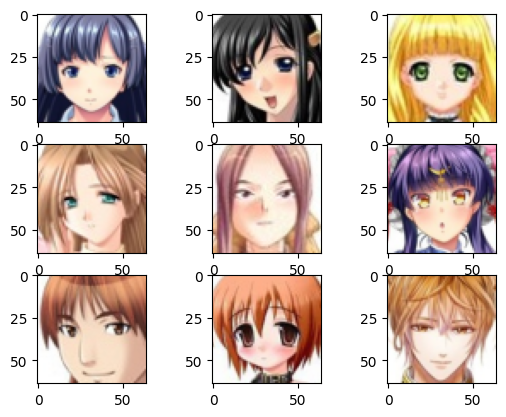

In [5]:
plot_tensor_images(random_images)

In [6]:
dataloader = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True)

## VAE

In [7]:
latent_dim = 20
model = DeepVAE(latent_dim=latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

trainer = VaeTrainer(
    model,
    10,
    optimizer,
)

trainer.train_with_loader(dataloader, device)

  0%|          | 0/1250 [00:00<?, ?it/s]

Epoch 1 of 10 finished. Loss is 4089917.2825.
Epoch 2 of 10 finished. Loss is 3729496.582.
Epoch 3 of 10 finished. Loss is 3614942.4635.
Epoch 4 of 10 finished. Loss is 3579939.7915.
Epoch 5 of 10 finished. Loss is 3551451.359.
Epoch 6 of 10 finished. Loss is 3537844.535.
Epoch 7 of 10 finished. Loss is 3525448.011.
Epoch 8 of 10 finished. Loss is 3523094.726.
Epoch 9 of 10 finished. Loss is 3516587.585.
Epoch 10 of 10 finished. Loss is 3517297.6135.


In [8]:
z = torch.randn(9, latent_dim).to(device)
generated_images = model.decode(z).cpu().detach().view(-1, 3, 64, 64)

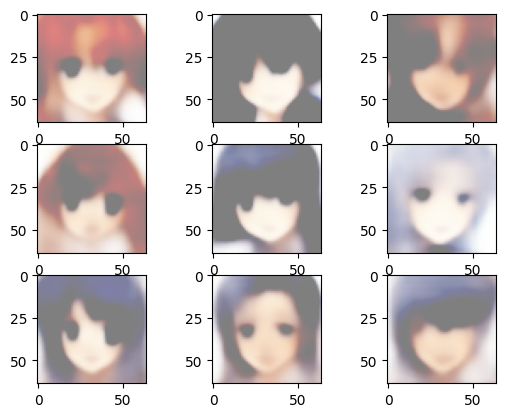

In [9]:
plot_tensor_images(generated_images)

## GAN

In [10]:
# Size of z latent vector (i.e. size of generator input)
nz = 100
num_epochs = 10

# Learning rate for optimizers
lr = 0.0002

# Beta1 hyperparameter for Adam optimizers
beta1 = 0.5

criterion = nn.BCELoss()
generator = gan.Generator(nz).to(device)
discriminator = gan.Discriminator().to(device)
generator_optimizer = optim.Adam(generator.parameters(), lr=lr, betas=(beta1, 0.999))
discriminator_optimizer = optim.Adam(
    discriminator.parameters(), lr=lr, betas=(beta1, 0.999)
)
trainer = GanTrainer(
    epochs=num_epochs,
    generator=generator,
    discriminator=discriminator,
    generator_optimizer=generator_optimizer,
    discriminator_optimizer=discriminator_optimizer,
    criterion=criterion,
    device=device,
)

In [11]:
trainer.train(dataloader, nz)

[0/10][0/125]	Loss_D: 2.1628	Loss_G: 18.9495	D(x): 0.3947	D(G(z)): 0.7086 / 0.0000
[0/10][50/125]	Loss_D: 0.0000	Loss_G: 12.6353	D(x): 1.0000	D(G(z)): 0.0000 / 0.0000
[0/10][100/125]	Loss_D: 0.0000	Loss_G: 29.1271	D(x): 1.0000	D(G(z)): 0.0000 / 0.0000
[1/10][0/125]	Loss_D: 0.0035	Loss_G: 6.8565	D(x): 0.9990	D(G(z)): 0.0025 / 0.0011
[1/10][50/125]	Loss_D: 3.8763	Loss_G: 37.5346	D(x): 0.0207	D(G(z)): 0.0000 / 0.0000
[1/10][100/125]	Loss_D: 0.0395	Loss_G: 4.3307	D(x): 1.0000	D(G(z)): 0.0387 / 0.0132
[2/10][0/125]	Loss_D: 5.4991	Loss_G: 3.7436	D(x): 0.0398	D(G(z)): 0.8972 / 0.0237
[2/10][50/125]	Loss_D: 0.0001	Loss_G: 11.3612	D(x): 1.0000	D(G(z)): 0.0000 / 0.0000
[2/10][100/125]	Loss_D: 2.3144	Loss_G: 7.9683	D(x): 0.3346	D(G(z)): 0.7047 / 0.0003
[3/10][0/125]	Loss_D: 0.0128	Loss_G: 4.9881	D(x): 0.9924	D(G(z)): 0.0052 / 0.0068
[3/10][50/125]	Loss_D: 0.6344	Loss_G: 7.7420	D(x): 0.7931	D(G(z)): 0.3314 / 0.0004
[3/10][100/125]	Loss_D: 0.6579	Loss_G: 5.5236	D(x): 1.0000	D(G(z)): 0.4820 / 0.0040

In [12]:
z = torch.randn(9, nz, 1, 1, device=device)
generated_images = generator(z).cpu().detach().view(-1, 3, 64, 64)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3836882..0.9813247].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.40989488..0.98219496].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.45510814..0.9897102].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49270192..0.982648].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.27535728..0.98056704].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.47262457..0.98826694].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0

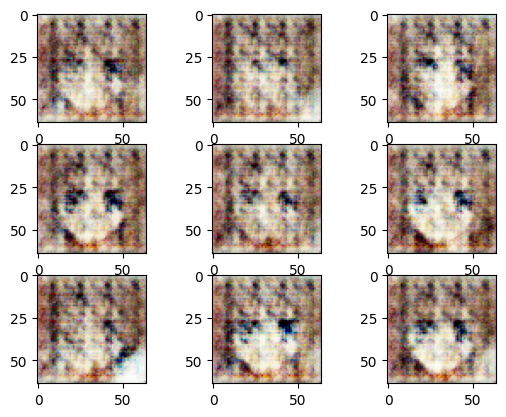

In [13]:
plot_tensor_images(generated_images)

## DCGAN

In [14]:
# Size of z latent vector (i.e. size of generator input)
nz = 100
num_epochs = 10

# Learning rate for optimizers
lr = 0.0002

# Beta1 hyperparameter for Adam optimizers
beta1 = 0.5

criterion = nn.BCELoss()
generator = dcgan.Generator(nz).to(device)
discriminator = dcgan.Discriminator().to(device)
generator_optimizer = optim.Adam(generator.parameters(), lr=lr, betas=(beta1, 0.999))
discriminator_optimizer = optim.Adam(
    discriminator.parameters(), lr=lr, betas=(beta1, 0.999)
)
trainer = GanTrainer(
    epochs=num_epochs,
    generator=generator,
    discriminator=discriminator,
    generator_optimizer=generator_optimizer,
    discriminator_optimizer=discriminator_optimizer,
    criterion=criterion,
    device=device
)

In [15]:
trainer.train(dataloader, nz)

[0/10][0/125]	Loss_D: 0.4150	Loss_G: 25.1766	D(x): 0.9207	D(G(z)): 0.2828 / 0.0000
[0/10][50/125]	Loss_D: 0.0020	Loss_G: 25.0586	D(x): 0.9980	D(G(z)): 0.0000 / 0.0000
[0/10][100/125]	Loss_D: 0.0010	Loss_G: 26.2144	D(x): 0.9990	D(G(z)): 0.0000 / 0.0000
[1/10][0/125]	Loss_D: 2.3307	Loss_G: 19.5373	D(x): 0.0972	D(G(z)): 0.0000 / 0.0000
[1/10][50/125]	Loss_D: 1.8047	Loss_G: 18.5341	D(x): 0.1645	D(G(z)): 0.0000 / 0.0000
[1/10][100/125]	Loss_D: 0.0016	Loss_G: 6.8662	D(x): 0.9992	D(G(z)): 0.0009 / 0.0010
[2/10][0/125]	Loss_D: 4.6576	Loss_G: 8.3301	D(x): 0.9864	D(G(z)): 0.9904 / 0.0002
[2/10][50/125]	Loss_D: 0.0040	Loss_G: 5.7828	D(x): 0.9989	D(G(z)): 0.0029 / 0.0031
[2/10][100/125]	Loss_D: 0.0109	Loss_G: 4.8836	D(x): 0.9998	D(G(z)): 0.0107 / 0.0076
[3/10][0/125]	Loss_D: 4.4680	Loss_G: 0.7417	D(x): 0.0122	D(G(z)): 0.0564 / 0.4763
[3/10][50/125]	Loss_D: 1.8130	Loss_G: 10.7184	D(x): 0.9995	D(G(z)): 0.8368 / 0.0000
[3/10][100/125]	Loss_D: 7.8291	Loss_G: 8.1572	D(x): 0.9997	D(G(z)): 0.9996 / 0.000

In [16]:
z = torch.randn(9, nz, 1, 1, device=device)
generated_images = generator(z).cpu().detach().view(-1, 3, 64, 64)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.41710076..0.9747694].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.23847772..0.9794228].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2649618..0.97827536].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.18709981..0.9909521].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.29609257..0.9826168].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.21390927..0.9811513].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.

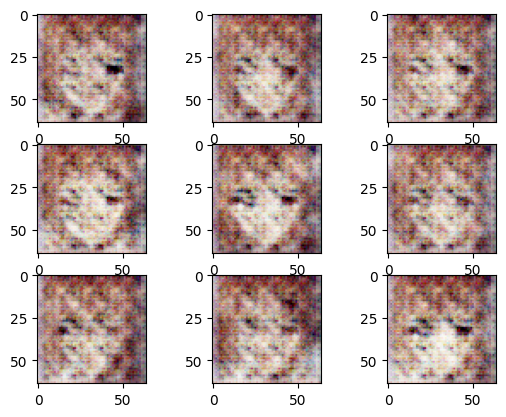

In [17]:
plot_tensor_images(generated_images)